# LangChain RAG Walkthrough with ChromaDB

This notebook demonstrates a complete Retrieval-Augmented Generation (RAG) implementation using:
- **LangChain** for orchestration
- **ChromaDB** as the vector store (ephemeral, no background processes)
- **Flexible LLM support** for OpenAI, Gemini, or Ollama
- **Document chunking** and **embedding** workflows
- **Similarity-based retrieval**

## Overview
1. Setup and Dependencies
2. Document Loading and Chunking
3. Embedding Generation
4. Vector Store Creation (ChromaDB)
5. Similarity Retrieval
6. LLM Integration (OpenAI/Gemini/Ollama)
7. Complete RAG Pipeline

In [2]:
# Install required packages
!pip install -qU langchain langchain-community langchain-openai langchain-google-genai chromadb sentence-transformers pypdf2 python-dotenv bs4 langchain-ollama

In [3]:
# Import required libraries

import os
from typing import List, Optional
from dotenv import load_dotenv

from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.docstore.document import Document
from langchain_community.vectorstores import Chroma
from langchain.schema import BaseRetriever
from langchain.prompts import PromptTemplate

from langchain.chat_models.base import init_chat_model

load_dotenv()  # Load environment variables from .env file

True

## 1. Document Preparation and Chunking

Step 1. Download a PDF of the RSECon schedule (URL)
Step 2. Load the PDF into memory using LangChain's PDF loader
Step 3. Demonstrate a document object

In [4]:
# Create/get sample documents for demonstration
from langchain_community.document_loaders import PyPDFLoader

file_path = "./rsecon_schedule.pdf"

loader = PyPDFLoader(file_path)
pages = []
async for page in loader.alazy_load():
    pages.append(page)

## Accessing content
The content of a Document object can be accessed via the page_content method.

In [5]:
print(pages[0].page_content)

RSECon25
Schedule
Monday, 8 September, 2025
09:30-16:30OC1.09
Back to Fortran Future 2 Satellite Event
Satellite Event
https://rsecon25.society-rse.org/back-to-fortran-future-2/
12:00-17:00OC1.01
RSE Leaders
Satellite Event
Satellite event – RSE leaders and aspiring leaders meeting
https://rsecon25.society-rse.org/leaders-meeting/
14:00-17:00The Oculus Atrium
Early Registration
17:00-18:00
NOTE: PROGRAMME SIGNIFICANTLY UPDATED 12/8
18:00-23:00Rootes Restaurant
Welcome social
Social
18:00-18:30
Meet & Greet: Settle In
Social
New to the conference, attending solo, or just want to meet new people? Join us for this relaxed session before the ﬁrst social kicks oﬀ. A chance to
connect with others in a welcoming space – open to all, especially those looking to ﬁnd friendly faces before the main events begin.
Tuesday, 9 September, 2025
08:15-09:00The Oculus Atrium
Main Registration
This is the dedicated window for registration before the sessions.  NOTE: Registration will be available 08:15 to

## Accessing metadata
Metadata can be accessed from the Document object via the metadata method.

In [6]:
# Demonstrate different chunking strategies
# Show user metadata and page content methods
pages[0].metadata



{'producer': 'Skia/PDF m133',
 'creator': 'Chromium',
 'creationdate': '2025-09-02T12:44:48+00:00',
 'title': 'Oxford Abstracts PDF Export',
 'moddate': '2025-09-02T12:44:48+00:00',
 'source': './rsecon_schedule.pdf',
 'total_pages': 11,
 'page': 0,
 'page_label': '1'}

## Chunking Documents

The next step is splitting or chunking your documents. Why do this?

- Limits the size of the page content of each `Document`.
- Embeddings are often more meaningful on smaller amounts of data.
- Groups text together in a more logical way, such as sentences and paragraphs as opposed to entire pages.

This is the information that is going to be retrieved to answer your question/prompt.

For this tutorial we will use the RecursiveCharacterTextSplitter - REFERENCE DOCUMENTATION

In [7]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Create final chunks for our RAG pipeline
# Using medium-sized chunks for optimal balance
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=400, # Chunk size - Explain?
    chunk_overlap=100, # Chunk overlap - Explain
)

chunks = text_splitter.split_documents(pages)

print('Total number of pages:', len(pages))
print('Total number of chunks:', len(chunks))

Total number of pages: 11
Total number of chunks: 34


## 2. Embedding Strategies

We will now discuss embeddings using Ollama.

We will embed the chunks that that we split prior to this and attach the embeddings to the Documents.

MAKE A DISTINCTION ABOUT DIMENTIONS LENGTHS ETC

In [46]:
from langchain.embeddings.base import init_embeddings

ollama_embeddings = init_embeddings(model="nomic-embed-text", provider="ollama")

embeddings = ollama_embeddings.embed_documents([chunk.page_content for chunk in chunks])  
print('The number of embeddings is:', len(embeddings), '(One per document)')
print('The length the embedding vector is:', len(embeddings[0]))

The number of embeddings is: 34 (One per document)
The length the embedding vector is: 768


In [47]:
print(chunks[0].page_content[100:])

nt
Satellite Event
https://rsecon25.society-rse.org/back-to-fortran-future-2/
12:00-17:00OC1.01
RSE Leaders
Satellite Event
Satellite event – RSE leaders and aspiring leaders meeting
https://rsecon25.society-rse.org/leaders-meeting/
14:00-17:00The Oculus Atrium
Early Registration
17:00-18:00


In [48]:
print(embeddings[0][0:10],'...\n',embeddings[0][-10:])

[-0.05079458, 0.049108934, -0.19633335, -0.014161628, 0.018977733, -0.039554313, 0.06755748, -0.039175205, 0.009551489, -0.047545783] ...
 [0.13374127, 0.016735403, 0.043416638, -0.037861474, 0.018090446, 0.0025199992, -0.00085057924, -0.045812164, -0.042318612, -0.018408764]


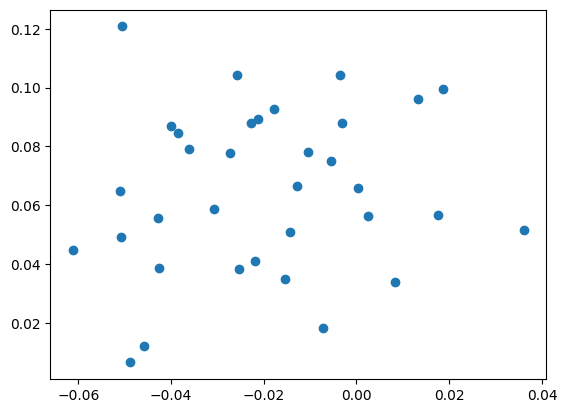

In [49]:
from matplotlib import pyplot as plt
import numpy as np

embeds = np.array(embeddings)

embeds.shape

plt.scatter(embeds[:,0], embeds[:,1])

In [ ]:
# Create ChromaDB vector store with persistence
import os
from langchain_chroma import Chroma

# Define the directory where ChromaDB will save the vector store
persist_directory = "./vectorstore"
print(f"Creating ChromaDB vector store with persistence at: {persist_directory}")

# Create the vector store with our chunks and embeddings
vectorstore = Chroma(
    collection_name="default_collection",
    embedding_function=ollama_embeddings,
    persist_directory="./vectorstore",  # Where to save data locally, remove if not necessary
)

vectorstore.delete(vectorstore.get()['ids']) # Cleans up any old documents that might exist in the VDB on first run.
document_ids = vectorstore.add_documents(chunks)
#document = vectorstore.get(document_ids[0], include=["embeddings", "metadatas", "documents"]) # Documents with embeddings added.
document = vectorstore.get(document_ids[0], include=["metadatas", "documents"])

document

Creating ChromaDB vector store with persistence at: ./vectorstore


{'ids': ['46f485ce-b60b-4fcd-8c72-aee3e36126ef'],
 'embeddings': None,
 'documents': ['RSECon25\nSchedule\nMonday, 8 September, 2025\n09:30-16:30OC1.09\nBack to Fortran Future 2 Satellite Event\nSatellite Event\nhttps://rsecon25.society-rse.org/back-to-fortran-future-2/\n12:00-17:00OC1.01\nRSE Leaders\nSatellite Event\nSatellite event – RSE leaders and aspiring leaders meeting\nhttps://rsecon25.society-rse.org/leaders-meeting/\n14:00-17:00The Oculus Atrium\nEarly Registration\n17:00-18:00'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [{'creator': 'Chromium',
   'source': './rsecon_schedule.pdf',
   'moddate': '2025-09-02T12:44:48+00:00',
   'page_label': '1',
   'creationdate': '2025-09-02T12:44:48+00:00',
   'page': 0,
   'title': 'Oxford Abstracts PDF Export',
   'producer': 'Skia/PDF m133',
   'total_pages': 11}]}

## 4. Similarity Retrieval

Retrieval is arguably one of the most important parts of RAG, it's how we get the context that our LLMs use to generate our responses.

A simple method of retrieval is the similarity search. This retrieves documents in the vectorstore by comparing embeddings.

Let's breakdown how the similarity search works by comparing two embeddings using a cosine similarity function.

In [103]:
# Demonstrate similarity search
from langchain_community.utils.math import cosine_similarity
import numpy as np

embedding_1 = ollama_embeddings.embed_query("What is machine learning?")
embedding_2 = ollama_embeddings.embed_query("What are neural networks?")
embedding_3 = ollama_embeddings.embed_query("What is deep learning?")
embedding_4 = ollama_embeddings.embed_query("The Eiffel Tower is in Paris.")
embedding_5 = ollama_embeddings.embed_query("What is the capital of France?")
embedding_6 = ollama_embeddings.embed_query("Quelle est la capitale de la France?")

similarity = cosine_similarity(
    [
        np.array(embedding_1),
        np.array(embedding_2),
        np.array(embedding_3),
        np.array(embedding_4),
        np.array(embedding_5),
        np.array(embedding_6),
    ],
    [
        np.array(embedding_1),
        np.array(embedding_2),
        np.array(embedding_3),
        np.array(embedding_4),
        np.array(embedding_5),
        np.array(embedding_6),
    ],
)
print(
    f"Similarity between 'machine learning' and 'neural networks': {similarity[0][1]:.4f}"
)
print(
    f"Similarity between 'machine learning' and 'deep learning': {similarity[0][2]:.4f}"
)
print(
    f"Similarity between 'machine learning' and 'Eiffel Tower': {similarity[0][3]:.4f}"
)
print(
    f"Similarity between 'machine learning' and 'capital of France': {similarity[0][4]:.4f}"
)
print(
    f"Similarity between 'Eiffel Tower' and 'capital of France': {similarity[3][4]:.4f}"
)
print(
    f"Similarity between 'Capital of France' and 'capitale de la France': {similarity[4][5]:.4f}"
)

Similarity between 'machine learning' and 'neural networks': 0.6392
Similarity between 'machine learning' and 'deep learning': 0.7244
Similarity between 'machine learning' and 'Eiffel Tower': 0.2901
Similarity between 'machine learning' and 'capital of France': 0.3270
Similarity between 'Eiffel Tower' and 'capital of France': 0.6603
Similarity between 'Capital of France' and 'capitale de la France': 0.8804


In [109]:
# Demonstrate similarity search
def test_similarity_search(query: str, k: int = 3):
    """Test similarity search with a given query"""
    print(f"\nQuery: '{query}'")
    print(f"Retrieving top {k} similar documents:")
    print("-" * 50)
    
    # Similarity search
    results = vectorstore.similarity_search(query, k=k)
    
    for i, doc in enumerate(results, 1):
        source = doc.metadata.get('source', 'unknown')
        print(f"{i}. Source: {source}")
        print(f"   Content: {doc.page_content[:150]}...")
        print()
    
    return results

# Test with different queries
test_queries = [
    "What time is the Retrieval-Augmented Generation walkthrough?",
]

for query in test_queries:
    test_similarity_search(query, k=10)



Query: 'What time is the Retrieval-Augmented Generation walkthrough?'
Retrieving top 10 similar documents:
--------------------------------------------------
1. Source: ./rsecon_schedule.pdf
   Content: Retrieval Augmented Generation
Deborah Udoh
Walkthrough
Presentation
14:00-14:30OC0.03
Embedding Energy Eﬃciency
Lata Nautiyal
Talk
Presentation
14:30...

2. Source: ./rsecon_schedule.pdf
   Content: 13:30-14:00OC0.03
JAX for Scientiﬁc Computing
Lata Nautiyal
Talk
Presentation
13:30-15:00OC0.02
HPCRSE
Birds of a Feather
Interactive Session
13:30-15...

3. Source: ./rsecon_schedule.pdf
   Content: Presentation
12:00-12:30OC0.03
A Performance Analysis Methoodology
Paul Richmond
Talk
Presentation
12:30-13:30The Oculus Atrium
Lunch
13:30-14:00OC1.0...

4. Source: ./rsecon_schedule.pdf
   Content: Thursday, 11 September, 2025
09:00-09:35OC1.05
Tania Allard: Paths for impactful software: or how to keep research and scientiﬁc software relevant for...

5. Source: ./rsecon_schedule.pdf
   Conte

## 5. LLM Integration (Ollama)

Now we'll set up flexible LLM integration that can work with different providers.

In [ ]:
# Configure different LLM providers
llm = init_chat_model(model="llama3.2:1b", model_provider='ollama')



AIMessage(content="I'm doing well, thanks for asking. Is there anything I can help you with or would you like to chat about something in particular?", additional_kwargs={}, response_metadata={'model': 'llama3.2:1b', 'created_at': '2025-09-02T15:23:32.430360103Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2494217388, 'load_duration': 1737198942, 'prompt_eval_count': 30, 'prompt_eval_duration': 60962141, 'eval_count': 29, 'eval_duration': 695531700, 'model_name': 'llama3.2:1b'}, id='run--7e7aebf8-47c3-42b8-9a9b-030b3db6d8ae-0', usage_metadata={'input_tokens': 30, 'output_tokens': 29, 'total_tokens': 59})